 All libraries imported successfully!
 SPOTIFY SONG POPULARITY PREDICTOR
 Using DEMO dataset (synthetic Spotify-style data)
   To use real Spotify data, set use_demo=False and add your API keys.

 Demo dataset ready: 2000 tracks | popularity range 18–100

═══════════════════════════════════════════════════════
   EXPLORATORY DATA ANALYSIS
═══════════════════════════════════════════════════════
                   count       mean       std        min        25%        50%        75%        max
danceability      2000.0       0.63      0.16       0.10       0.53       0.64       0.75       0.98
energy            2000.0       0.57      0.17       0.07       0.44       0.57       0.69       0.97
loudness          2000.0     -12.21      7.22     -24.98     -18.45     -12.31      -6.01      -0.00
speechiness       2000.0       0.07      0.07       0.00       0.02       0.05       0.10       0.65
acousticness      2000.0       0.28      0.16       0.00       0.16       0.27       0.38       0.

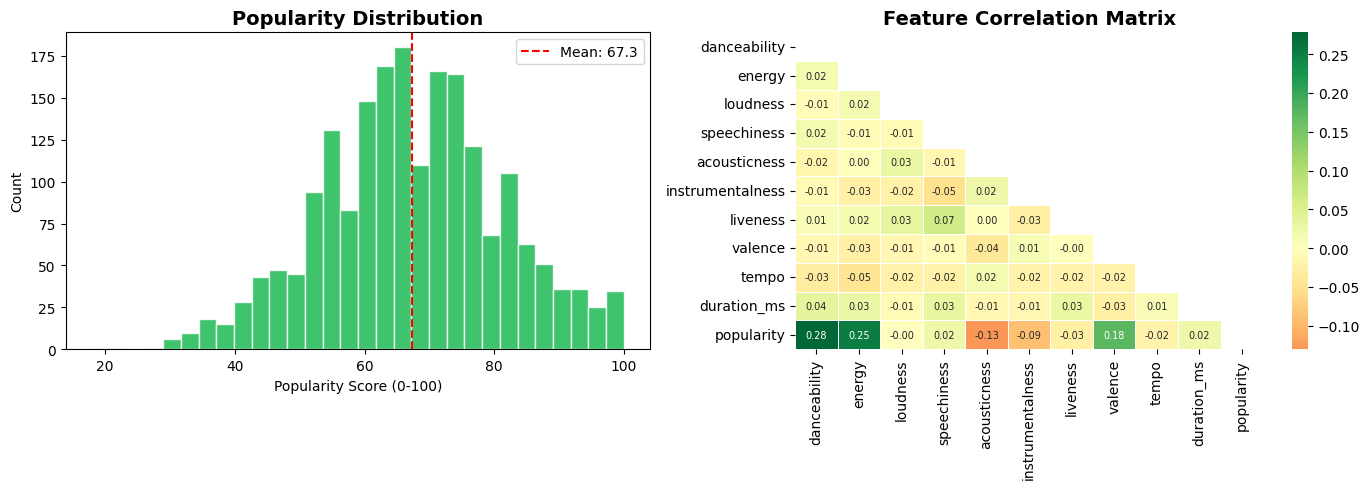

  ✓ EDA charts saved to eda_overview.png


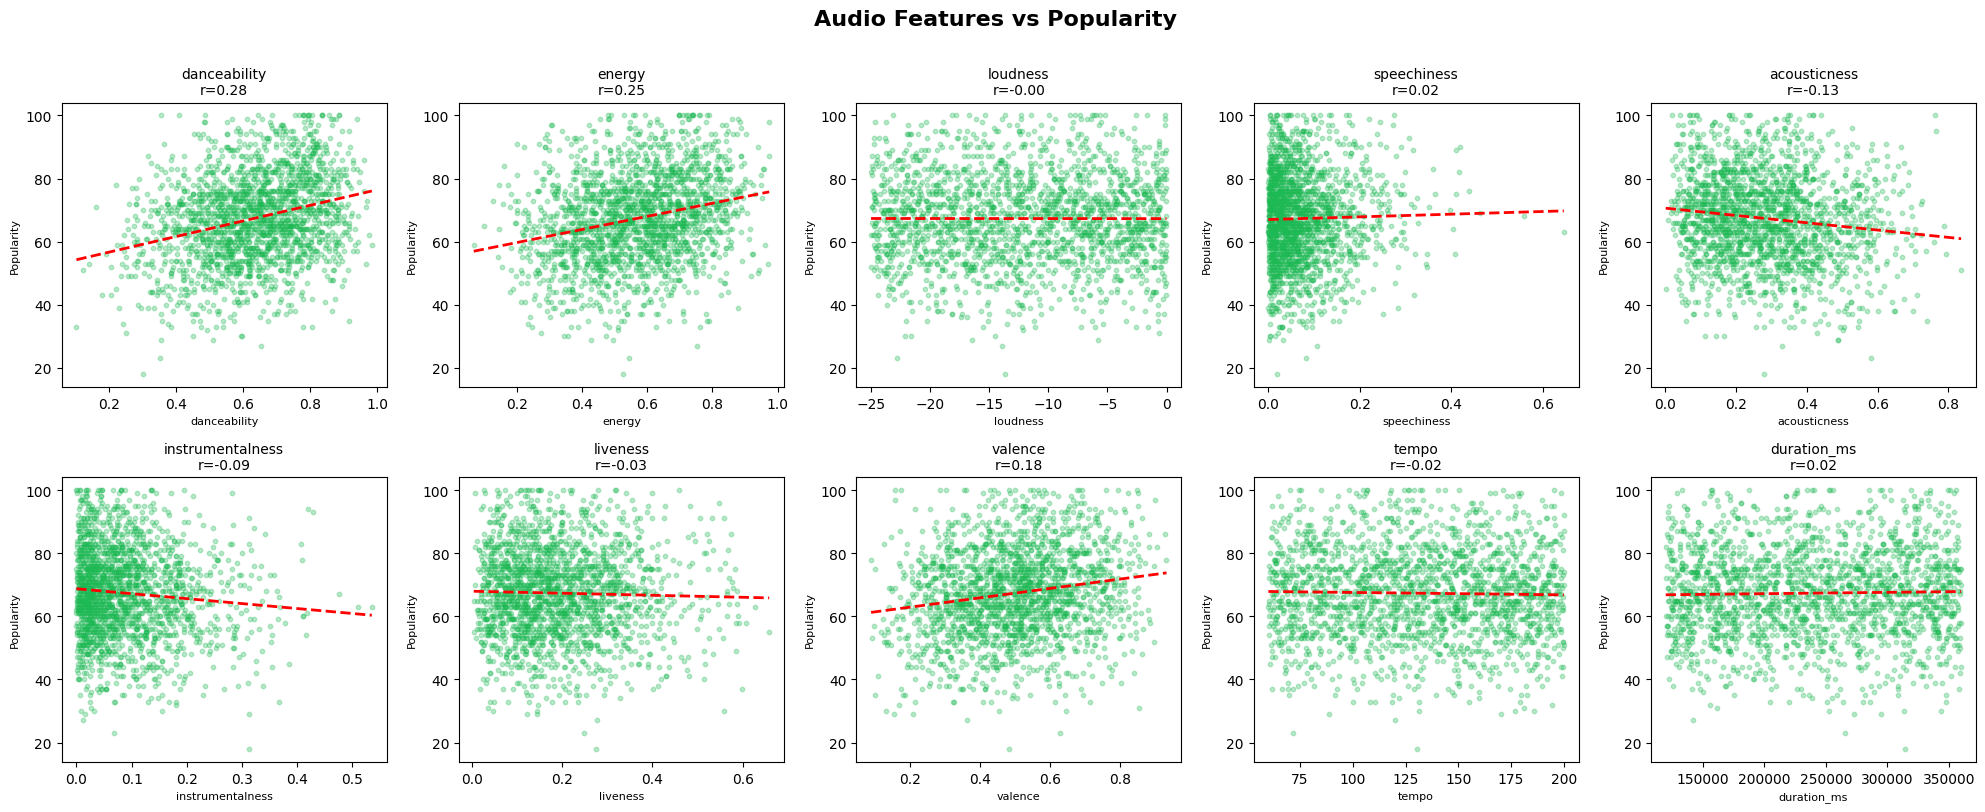

  ✓ Scatter grid saved to feature_scatter.png

 Engineering features...
  ✓ Feature count: 27 columns
  Train: 1600 | Test: 400 | Features: 23

═══════════════════════════════════════════════════════
  🤖 MODEL TRAINING
═══════════════════════════════════════════════════════

[1/3] Training XGBoost Regressor...
  RMSE=13.14  MAE=10.60  R²=0.222

[2/3] Training LightGBM Regressor...
  RMSE=13.29  MAE=10.71  R²=0.204

[3/3] Training XGBoost Classifier (Popular ≥ 60)...
              precision    recall  f1-score   support

           0       0.55      0.39      0.46       119
           1       0.77      0.87      0.82       281

    accuracy                           0.72       400
   macro avg       0.66      0.63      0.64       400
weighted avg       0.71      0.72      0.71       400


═══════════════════════════════════════════════════════
  📈 EVALUATION & VISUALISATION
═══════════════════════════════════════════════════════


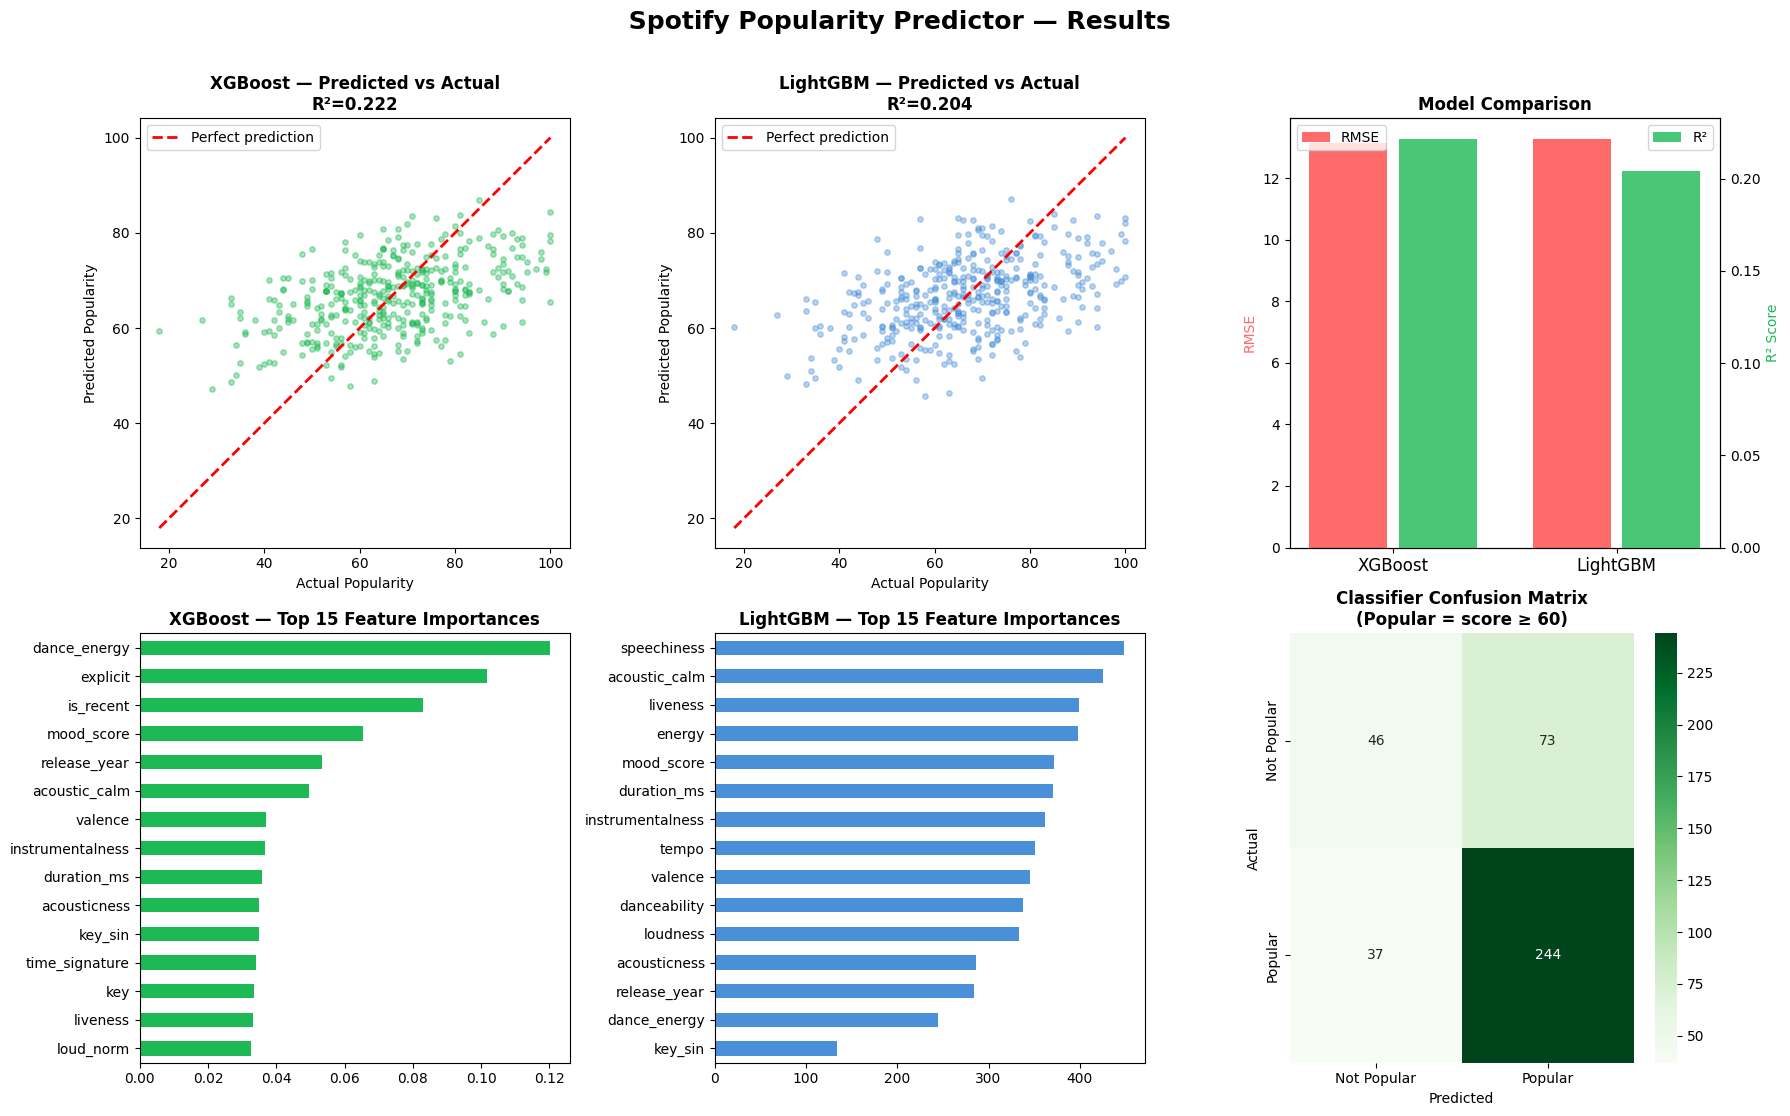

  ✓ Results chart saved to model_results.png

═══════════════════════════════════════════════════════
  SHAP EXPLAINABILITY — XGBoost
═══════════════════════════════════════════════════════


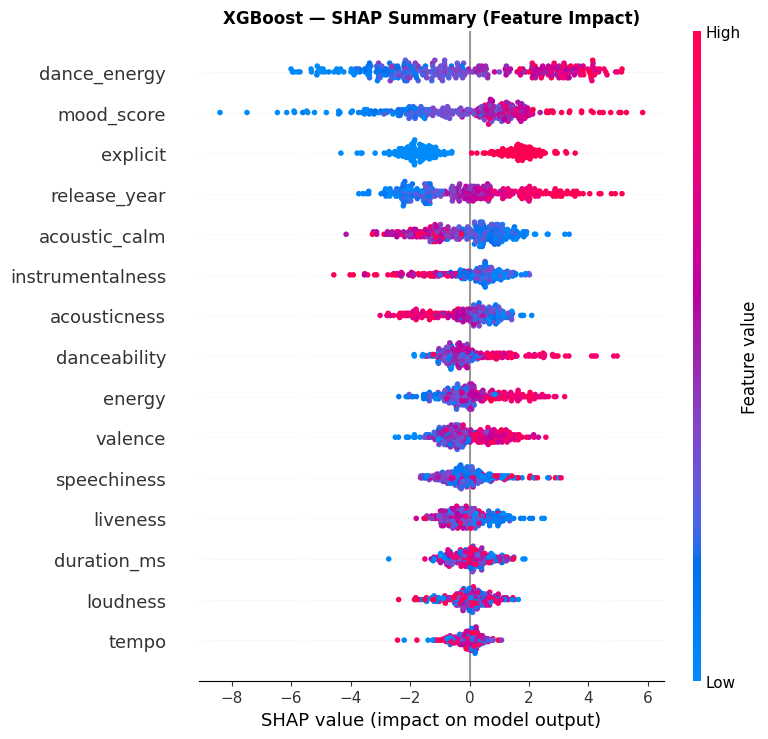

  ✓ SHAP summary saved to shap_summary.png


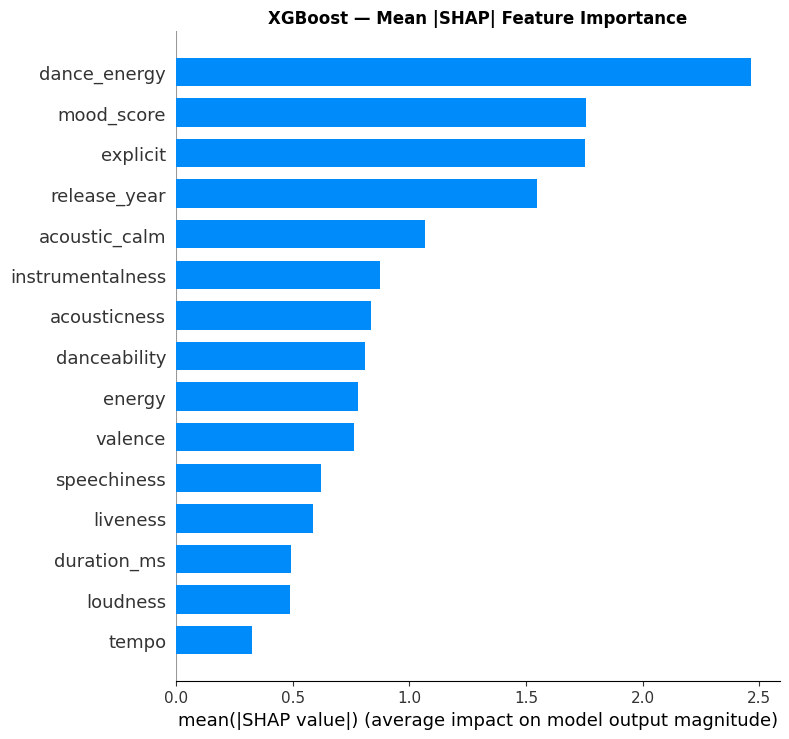

  ✓ SHAP importance saved to shap_importance.png


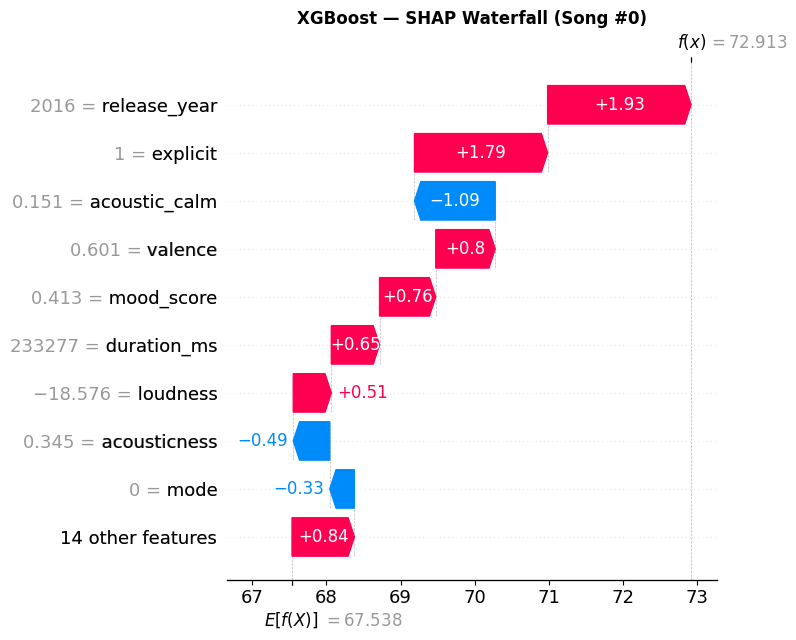

  ✓ SHAP waterfall saved to shap_waterfall.png

 Prediction for: 'Summer Banger 2024'
   XGBoost  → 83.9/100
   LightGBM → 90.8/100
   Ensemble → 87.3/100
  Prediction: HIT POTENTIAL!

 Pipeline complete! Check the saved .png charts.


In [5]:
!pip install numpy pandas scikit-learn matplotlib seaborn xgboost lightgbm shap spotipy
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score,
                              mean_absolute_error, classification_report,
                              confusion_matrix)
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb
import lightgbm as lgb
import shap

warnings.filterwarnings("ignore")
print(" All libraries imported successfully!")



SPOTIFY_CLIENT_ID     = "edfb68ba547b40a0906729d8d6afb76f"
SPOTIFY_CLIENT_SECRET = "b8e0dc0569354c2782ae2237b9b21b31"

def collect_spotify_data(use_demo=True):
    """
    Collect track data from Spotify API.
    If use_demo=True, generates realistic synthetic data so you
    can run the entire pipeline without API credentials.
    """
    if use_demo:
        print(" Using DEMO dataset (synthetic Spotify-style data)")
        print("   To use real Spotify data, set use_demo=False and add your API keys.\n")
        return generate_demo_dataset()


    try:
        import spotipy
        from spotipy.oauth2 import SpotifyClientCredentials
    except ImportError:
        raise ImportError("Run: pip install spotipy")

    auth = SpotifyClientCredentials(
        client_id=SPOTIFY_CLIENT_ID,
        client_secret=SPOTIFY_CLIENT_SECRET
    )
    sp = spotipy.Spotify(auth_manager=auth)


    playlist_ids = [
        "37i9dQZF1DXcBWIGoYBM5M",
        "37i9dQZF1DX0XUsuxWHRQd",
        "37i9dQZF1DX4dyzvuaRJ0n",
        "37i9dQZF1DX4o1oenSJRJd",
        "37i9dQZF1DWXRqgorJj26U",
    ]

    all_tracks = []
    for pid in playlist_ids:
        try:
            results = sp.playlist_tracks(pid, limit=100)
            track_ids = [item['track']['id'] for item in results['items']
                         if item['track'] and item['track']['id']]

            for i in range(0, len(track_ids), 50):
                batch = track_ids[i:i+50]
                features = sp.audio_features(batch)
                tracks   = sp.tracks(batch)['tracks']
                for feat, track in zip(features, tracks):
                    if feat and track:
                        row = {**feat,
                               'name':       track['name'],
                               'artist':     track['artists'][0]['name'],
                               'popularity': track['popularity'],
                               'explicit':   int(track['explicit']),
                               'release_year': int(track['album']['release_date'][:4])
                                              if track['album']['release_date'] else 2020}
                        all_tracks.append(row)
            time.sleep(0.5)
            print(f"  ✓ Fetched playlist {pid[:8]}...")
        except Exception as e:
            print(f"  ✗ Skipped {pid[:8]}: {e}")

    df = pd.DataFrame(all_tracks).drop_duplicates(subset='id')
    print(f"\n Collected {len(df)} unique tracks from Spotify API")
    return df


def generate_demo_dataset(n=2000, seed=42):
    """Generate realistic synthetic Spotify audio feature data."""
    np.random.seed(seed)
    n = int(n)

    df = pd.DataFrame({
        'danceability':     np.clip(np.random.beta(5, 3, n), 0, 1),
        'energy':           np.clip(np.random.beta(4, 3, n), 0, 1),
        'loudness':         np.random.uniform(-25, 0, n),
        'speechiness':      np.clip(np.random.exponential(0.07, n), 0, 1),
        'acousticness':     np.clip(np.random.beta(2, 5, n), 0, 1),
        'instrumentalness': np.clip(np.random.beta(1, 10, n), 0, 1),
        'liveness':         np.clip(np.random.beta(2, 8, n), 0, 1),
        'valence':          np.clip(np.random.beta(4, 4, n), 0, 1),
        'tempo':            np.random.uniform(60, 200, n),
        'duration_ms':      np.random.randint(120_000, 360_000, n),
        'key':              np.random.randint(0, 12, n),
        'mode':             np.random.randint(0, 2, n),
        'time_signature':   np.random.choice([3, 4, 5], n, p=[0.1, 0.85, 0.05]),
        'explicit':         np.random.randint(0, 2, n),
        'release_year':     np.random.randint(1990, 2025, n),
    })


    popularity = (
        30
        + 25 * df['danceability']
        + 20 * df['energy']
        + 15 * df['valence']
        - 10 * df['acousticness']
        - 15 * df['instrumentalness']
        +  5 * df['explicit']
        + 10 * ((df['release_year'] - 1990) / 35)
        + np.random.normal(0, 12, n)
    )
    df['popularity'] = np.clip(popularity, 0, 100).astype(int)
    print(f" Demo dataset ready: {len(df)} tracks | "
          f"popularity range {df['popularity'].min()}–{df['popularity'].max()}")
    return df



def run_eda(df):
    print("\n" + "═"*55)
    print("   EXPLORATORY DATA ANALYSIS")
    print("═"*55)
    print(df.describe().T.round(2).to_string())

    audio_features = ['danceability','energy','loudness','speechiness',
                      'acousticness','instrumentalness','liveness',
                      'valence','tempo','duration_ms']


    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(df['popularity'], bins=30, color='#1DB954', edgecolor='white', alpha=0.85)
    axes[0].set_title('Popularity Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Popularity Score (0-100)')
    axes[0].set_ylabel('Count')
    axes[0].axvline(df['popularity'].mean(), color='red', linestyle='--',
                    label=f"Mean: {df['popularity'].mean():.1f}")
    axes[0].legend()


    corr = df[audio_features + ['popularity']].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, ax=axes[1], cmap='RdYlGn', center=0,
                annot=True, fmt='.2f', linewidths=0.5, annot_kws={"size": 7})
    axes[1].set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✓ EDA charts saved to eda_overview.png")


    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    for i, feat in enumerate(audio_features):
        axes[i].scatter(df[feat], df['popularity'], alpha=0.3, s=10, color='#1DB954')
        z = np.polyfit(df[feat], df['popularity'], 1)
        p = np.poly1d(z)
        xs = np.linspace(df[feat].min(), df[feat].max(), 100)
        axes[i].plot(xs, p(xs), "r--", linewidth=2)
        corr_val = df[feat].corr(df['popularity'])
        axes[i].set_title(f'{feat}\nr={corr_val:.2f}', fontsize=10)
        axes[i].set_xlabel(feat, fontsize=8)
        axes[i].set_ylabel('Popularity', fontsize=8)
    plt.suptitle('Audio Features vs Popularity', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('feature_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✓ Scatter grid saved to feature_scatter.png")



def engineer_features(df):
    print("\n Engineering features...")
    df = df.copy()


    df['dance_energy']     = df['danceability'] * df['energy']
    df['mood_score']       = df['valence'] * df['danceability']
    df['acoustic_calm']    = df['acousticness'] * (1 - df['energy'])
    df['loud_norm']        = (df['loudness'] + 60) / 60
    df['duration_min']     = df['duration_ms'] / 60_000
    df['is_recent']        = (df['release_year'] >= 2018).astype(int)
    df['tempo_bin']        = pd.cut(df['tempo'],
                                    bins=[0, 80, 110, 140, 300],
                                    labels=['slow','mid','fast','very_fast'])
    df = pd.get_dummies(df, columns=['tempo_bin'], drop_first=True)


    df['key_sin'] = np.sin(2 * np.pi * df['key'] / 12)
    df['key_cos'] = np.cos(2 * np.pi * df['key'] / 12)

    print(f"  ✓ Feature count: {df.shape[1]} columns")
    return df



def prepare_data(df):
    drop_cols = [c for c in ['id','uri','track_href','analysis_url',
                              'type','name','artist'] if c in df.columns]
    df = df.drop(columns=drop_cols)


    y_reg = df['popularity'].values
    y_clf = (df['popularity'] >= 60).astype(int).values
    X     = df.drop(columns=['popularity'])


    X = X.select_dtypes(include=[np.number])

    X_train, X_test, yr_train, yr_test, yc_train, yc_test = train_test_split(
        X, y_reg, y_clf, test_size=0.2, random_state=42
    )

    scaler  = StandardScaler()
    Xs_train = scaler.fit_transform(X_train)
    Xs_test  = scaler.transform(X_test)

    print(f"  Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Features: {X_train.shape[1]}")
    return (X_train, X_test, Xs_train, Xs_test,
            yr_train, yr_test, yc_train, yc_test,
            X.columns.tolist(), scaler)



def train_models(X_train, X_test, yr_train, yr_test,
                 yc_train, yc_test, feature_names):
    print("\n" + "═"*55)
    print("  🤖 MODEL TRAINING")
    print("═"*55)
    results = {}


    print("\n[1/3] Training XGBoost Regressor...")
    xgb_reg = xgb.XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0
    )
    xgb_reg.fit(X_train, yr_train,
                eval_set=[(X_test, yr_test)],
                verbose=False)
    yr_pred_xgb = xgb_reg.predict(X_test)

    rmse_xgb = np.sqrt(mean_squared_error(yr_test, yr_pred_xgb))
    mae_xgb  = mean_absolute_error(yr_test, yr_pred_xgb)
    r2_xgb   = r2_score(yr_test, yr_pred_xgb)
    results['XGBoost'] = {'model': xgb_reg, 'pred': yr_pred_xgb,
                           'rmse': rmse_xgb, 'mae': mae_xgb, 'r2': r2_xgb}
    print(f"  RMSE={rmse_xgb:.2f}  MAE={mae_xgb:.2f}  R²={r2_xgb:.3f}")


    print("\n[2/3] Training LightGBM Regressor...")
    lgb_reg = lgb.LGBMRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1
    )
    lgb_reg.fit(X_train, yr_train,
                eval_set=[(X_test, yr_test)])
    yr_pred_lgb = lgb_reg.predict(X_test)

    rmse_lgb = np.sqrt(mean_squared_error(yr_test, yr_pred_lgb))
    mae_lgb  = mean_absolute_error(yr_test, yr_pred_lgb)
    r2_lgb   = r2_score(yr_test, yr_pred_lgb)
    results['LightGBM'] = {'model': lgb_reg, 'pred': yr_pred_lgb,
                            'rmse': rmse_lgb, 'mae': mae_lgb, 'r2': r2_lgb}
    print(f"  RMSE={rmse_lgb:.2f}  MAE={mae_lgb:.2f}  R²={r2_lgb:.3f}")


    print("\n[3/3] Training XGBoost Classifier (Popular ≥ 60)...")
    xgb_clf = xgb.XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, verbosity=0
    )
    xgb_clf.fit(X_train, yc_train)
    yc_pred = xgb_clf.predict(X_test)
    results['Classifier'] = {'model': xgb_clf, 'pred': yc_pred,
                               'report': classification_report(yc_test, yc_pred)}
    print(results['Classifier']['report'])

    return results, yr_test, yc_test



def evaluate_and_visualise(results, yr_test, yc_test, feature_names):
    print("\n" + "═"*55)
    print("  📈 EVALUATION & VISUALISATION")
    print("═"*55)

    fig, axes = plt.subplots(2, 3, figsize=(18, 11))


    ax = axes[0, 0]
    ax.scatter(yr_test, results['XGBoost']['pred'],
               alpha=0.4, s=15, color='#1DB954')
    lims = [min(yr_test.min(), results['XGBoost']['pred'].min()),
            max(yr_test.max(), results['XGBoost']['pred'].max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
    ax.set_xlabel('Actual Popularity'); ax.set_ylabel('Predicted Popularity')
    ax.set_title(f"XGBoost — Predicted vs Actual\nR²={results['XGBoost']['r2']:.3f}", fontweight='bold')
    ax.legend()


    ax = axes[0, 1]
    ax.scatter(yr_test, results['LightGBM']['pred'],
               alpha=0.4, s=15, color='#4A90D9')
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
    ax.set_xlabel('Actual Popularity'); ax.set_ylabel('Predicted Popularity')
    ax.set_title(f"LightGBM — Predicted vs Actual\nR²={results['LightGBM']['r2']:.3f}", fontweight='bold')
    ax.legend()


    ax = axes[0, 2]
    models = ['XGBoost', 'LightGBM']
    rmses  = [results[m]['rmse'] for m in models]
    r2s    = [results[m]['r2']   for m in models]
    x = np.arange(len(models))
    bars = ax.bar(x - 0.2, rmses, 0.35, label='RMSE', color='#FF6B6B')
    ax2b = ax.twinx()
    ax2b.bar(x + 0.2, r2s, 0.35, label='R²', color='#1DB954', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(models, fontsize=12)
    ax.set_ylabel('RMSE', color='#FF6B6B')
    ax2b.set_ylabel('R² Score', color='#1DB954')
    ax.set_title('Model Comparison', fontweight='bold')
    ax.legend(loc='upper left'); ax2b.legend(loc='upper right')


    ax = axes[1, 0]
    imp_xgb = pd.Series(results['XGBoost']['model'].feature_importances_,
                         index=feature_names).sort_values(ascending=False).head(15)
    imp_xgb.plot(kind='barh', ax=ax, color='#1DB954')
    ax.set_title('XGBoost — Top 15 Feature Importances', fontweight='bold')
    ax.invert_yaxis()


    ax = axes[1, 1]
    imp_lgb = pd.Series(results['LightGBM']['model'].feature_importances_,
                         index=feature_names).sort_values(ascending=False).head(15)
    imp_lgb.plot(kind='barh', ax=ax, color='#4A90D9')
    ax.set_title('LightGBM — Top 15 Feature Importances', fontweight='bold')
    ax.invert_yaxis()


    ax = axes[1, 2]
    cm = confusion_matrix(yc_test, results['Classifier']['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Not Popular','Popular'],
                yticklabels=['Not Popular','Popular'], ax=ax)
    ax.set_title('Classifier Confusion Matrix\n(Popular = score ≥ 60)', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

    plt.suptitle(' Spotify Popularity Predictor — Results', fontsize=18, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✓ Results chart saved to model_results.png")



def explain_with_shap(model, X_test, feature_names, model_name="XGBoost"):
    print(f"\n" + "═"*55)
    print(f"  SHAP EXPLAINABILITY — {model_name}")
    print("═"*55)

    X_df    = pd.DataFrame(X_test, columns=feature_names)
    sample  = X_df.sample(min(300, len(X_df)), random_state=42)
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(sample)

    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_vals, sample, plot_type="dot", show=False,
                      max_display=15)
    plt.title(f'{model_name} — SHAP Summary (Feature Impact)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✓ SHAP summary saved to shap_summary.png")

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, sample, plot_type="bar", show=False,
                      max_display=15)
    plt.title(f'{model_name} — Mean |SHAP| Feature Importance', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✓ SHAP importance saved to shap_importance.png")

    idx = 0
    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(
        shap.Explanation(values=shap_vals[idx],
                         base_values=explainer.expected_value,
                         data=sample.iloc[idx],
                         feature_names=feature_names),
        show=False
    )
    plt.title(f'{model_name} — SHAP Waterfall (Song #{idx})', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✓ SHAP waterfall saved to shap_waterfall.png")

    return shap_vals, sample



def predict_new_song(xgb_model, lgb_model, scaler, feature_names,
                     song_name="My New Track", **audio_features):
    """
    Predict popularity for a custom song.
    Pass any Spotify audio feature as a keyword argument.
    """
    defaults = dict(
        danceability=0.75, energy=0.80, loudness=-5.0, speechiness=0.06,
        acousticness=0.10, instrumentalness=0.00, liveness=0.12,
        valence=0.65, tempo=120.0, duration_ms=210_000,
        key=5, mode=1, time_signature=4, explicit=0, release_year=2024,

        dance_energy=0.75*0.80, mood_score=0.65*0.75, acoustic_calm=0.10*(1-0.80),
        loud_norm=((-5.0+60)/60), duration_min=210_000/60_000,
        is_recent=1, key_sin=np.sin(2*np.pi*5/12), key_cos=np.cos(2*np.pi*5/12)
    )
    defaults.update(audio_features)


    row = {f: defaults.get(f, 0) for f in feature_names}
    X_new = pd.DataFrame([row])[feature_names]


    for col in feature_names:
        if col not in X_new.columns:
            X_new[col] = 0

    pred_xgb = xgb_model.predict(X_new)[0]
    pred_lgb = lgb_model.predict(X_new)[0]
    pred_avg = (pred_xgb + pred_lgb) / 2

    print(f"\n Prediction for: '{song_name}'")
    print(f"   XGBoost  → {pred_xgb:.1f}/100")
    print(f"   LightGBM → {pred_lgb:.1f}/100")
    print(f"   Ensemble → {pred_avg:.1f}/100")
    if pred_avg >= 70:
        print("  Prediction: HIT POTENTIAL!")
    elif pred_avg >= 50:
        print(" Prediction: Decent track, moderate popularity")
    else:
        print(" Prediction: May struggle to gain traction")
    return pred_avg



if __name__ == "__main__":
    print("=" * 55)
    print(" SPOTIFY SONG POPULARITY PREDICTOR")
    print("=" * 55)


    df_raw = collect_spotify_data(use_demo=True)

    run_eda(df_raw)

    df_feat = engineer_features(df_raw)

    (X_train, X_test, Xs_train, Xs_test,
     yr_train, yr_test, yc_train, yc_test,
     feature_names, scaler) = prepare_data(df_feat)

    results, yr_test, yc_test = train_models(
        X_train, X_test, yr_train, yr_test, yc_train, yc_test, feature_names
    )


    evaluate_and_visualise(results, yr_test, yc_test, feature_names)

    shap_vals, shap_sample = explain_with_shap(
        results['XGBoost']['model'], X_test, feature_names, "XGBoost"
    )

    predict_new_song(
        results['XGBoost']['model'],
        results['LightGBM']['model'],
        scaler, feature_names,
        song_name="Summer Banger 2024",
        danceability=0.82, energy=0.90, valence=0.75,
        tempo=128, loudness=-4.5, release_year=2024,
        explicit=1
    )

    print("\n Pipeline complete! Check the saved .png charts.")